<a href="https://colab.research.google.com/github/tejinderpa/Deep-Learning/blob/Going-Deep/Credit_Risk_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:

df = pd.read_csv("Credit-risk.csv", skip_blank_lines=True)

# Drop completely empty columns (all values are NaN or empty)
df = df.dropna(axis=1, how='all')

# Drop completely empty rows
df = df.dropna(axis=0, how='all')

df.to_csv("cleaned_file1.csv", index=False)

df = pd.read_csv("cleaned_file1.csv", skip_blank_lines=True)


df.head()

,id,name,age,gender,marital_status,education_level,residence_type,residence_location,years_at_current_residence,state,...,proposed_monthly_emi,collateral_offered,collateral_type,collateral_value,has_previous_loans,missed_payment_count,job_change_count_last_3_years,electricity_bill_payment_status,mobile_bill_payment_status,legal_cases_pending
0,1.0,Raj Sharma,35.0,Male,Married,Graduate,Owned,City,7.0,Maharashtra,...,31500.0,Yes,Property,4500000.0,Yes,1,1.0,Regular,Regular,No
1,2.0,Priya Patel,28.0,Female,Single,Post Graduate,Rented,City,3.0,Gujarat,...,15500.0,No,NaN,0.0,Yes,0,2.0,Regular,Regular,No
2,3.0,Arun Kumar,45.0,Male,Married,Graduate,Owned,Town,15.0,Tamil Nadu,...,62500.0,Yes,Property,6000000.0,Yes,3,0.0,Irregular,Regular,No
3,4.0,Sunita Devi,50.0,Female,Divorced,School,Family,Village,30.0,Bihar,...,6500.0,No,NaN,0.0,No,0,0.0,Regular,Regular,Yes
4,5.0,Sanjay Mehta,60.0,Male,Married,Post Graduate,Owned,City,25.0,Delhi,...,16500.0,Yes,FD,2500000.0,Yes,0,0.0,Regular,Regular,No


In [55]:
legal_cases_pending_index = df.columns.get_loc('legal_cases_pending')
df = df.iloc[:, :legal_cases_pending_index + 1]
display(df.head())

,id,name,age,gender,marital_status,education_level,residence_type,residence_location,years_at_current_residence,state,...,proposed_monthly_emi,collateral_offered,collateral_type,collateral_value,has_previous_loans,missed_payment_count,job_change_count_last_3_years,electricity_bill_payment_status,mobile_bill_payment_status,legal_cases_pending
0,1.0,Raj Sharma,35.0,Male,Married,Graduate,Owned,City,7.0,Maharashtra,...,31500.0,Yes,Property,4500000.0,Yes,1,1.0,Regular,Regular,No
1,2.0,Priya Patel,28.0,Female,Single,Post Graduate,Rented,City,3.0,Gujarat,...,15500.0,No,NaN,0.0,Yes,0,2.0,Regular,Regular,No
2,3.0,Arun Kumar,45.0,Male,Married,Graduate,Owned,Town,15.0,Tamil Nadu,...,62500.0,Yes,Property,6000000.0,Yes,3,0.0,Irregular,Regular,No
3,4.0,Sunita Devi,50.0,Female,Divorced,School,Family,Village,30.0,Bihar,...,6500.0,No,NaN,0.0,No,0,0.0,Regular,Regular,Yes
4,5.0,Sanjay Mehta,60.0,Male,Married,Post Graduate,Owned,City,25.0,Delhi,...,16500.0,Yes,FD,2500000.0,Yes,0,0.0,Regular,Regular,No


In [56]:
df.columns

Index(['id', 'name', 'age', 'gender', 'marital_status', 'education_level',
       'residence_type', 'residence_location', 'years_at_current_residence',
       'state', 'pin_code', 'employment_type', 'years_of_experience',
       'years_with_current_employer', 'monthly_salary', 'annual_income',
       'other_income_sources', 'total_other_income_amount', 'total_income',
       'credit_score', 'existing_loans_count', 'existing_total_loan_amount',
       'current_credit_card_count', 'total_credit_utilization_percent',
       'any_default_in_last_24_months', 'last_default_date',
       'other_banks_feedback_rating',
       'recent_loan_enquiries_count_last_6_months',
       'emi_to_income_ratio_percent', 'total_monthly_emis',
       'bank_balance_average_last_6_months', 'family_member_count',
       'dependent_count', 'family_income_total', 'family_member_1_income',
       'family_member_2_income', 'family_member_3_income',
       'dependent_1_relation', 'dependent_1_age', 'owns_real_estate

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 67 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   id                                         151 non-null    float64
 1   name                                       151 non-null    object 
 2   age                                        151 non-null    float64
 3   gender                                     151 non-null    object 
 4   marital_status                             151 non-null    object 
 5   education_level                            151 non-null    object 
 6   residence_type                             151 non-null    object 
 7   residence_location                         151 non-null    object 
 8   years_at_current_residence                 151 non-null    float64
 9   state                                      151 non-null    object 
 10  pin_code                  

In [43]:
df.isnull().sum()

,0
id,0
name,0
age,0
gender,0
marital_status,0
...,...
missed_payment_count,0
job_change_count_last_3_years,0
electricity_bill_payment_status,0
mobile_bill_payment_status,0


In [44]:
df.describe()

,id,age,years_at_current_residence,pin_code,years_of_experience,years_with_current_employer,monthly_salary,annual_income,total_other_income_amount,total_income,...,real_estate_property_value,gold_or_jewelry_value,mutual_funds_value,stock_portfolio_value,crypto_assets_value,rental_income_per_month,requested_loan_tenure_months,proposed_monthly_emi,collateral_value,job_change_count_last_3_years
count,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,1.510000e+02,151.000000,1.510000e+02,...,1.510000e+02,151.00000,151.000000,1.510000e+02,151.000000,151.000000,1.510000e+02,151.000000,1.430000e+02,151.000000
mean,76.039735,36.920530,11.251656,316570.993377,14.225166,10.695364,47894.039735,7.687682e+05,76536.423841,8.453046e+05,...,2.609934e+06,227384.10596,268807.947020,3.265232e+05,21986.754967,3125.827815,5.708713e+04,23203.364238,1.546853e+06,1.052980
std,43.800743,8.166209,7.729785,174642.208749,7.792451,7.830703,29907.446635,1.417270e+05,72642.574737,1.764641e+05,...,2.884528e+06,142941.52002,168325.783932,2.686150e+05,52485.170827,5713.898873,2.458713e+05,12056.961272,1.841608e+06,0.854697
min,1.000000,24.000000,1.000000,110001.000000,2.000000,0.000000,0.000000,4.800000e+05,0.000000,5.040000e+05,...,0.000000e+00,0.00000,25000.000000,0.000000e+00,0.000000,0.000000,3.600000e+01,96.000000,0.000000e+00,0.000000
25%,38.500000,30.000000,4.000000,216001.000000,8.000000,4.000000,0.000000,6.720000e+05,0.000000,7.140000e+05,...,0.000000e+00,110000.00000,150000.000000,1.200000e+05,0.000000,0.000000,9.600000e+01,13500.000000,0.000000e+00,0.000000
50%,76.000000,36.000000,11.000000,271001.000000,13.000000,8.000000,59000.000000,7.800000e+05,84000.000000,8.640000e+05,...,0.000000e+00,150000.00000,220000.000000,2.800000e+05,0.000000,0.000000,1.440000e+02,22500.000000,0.000000e+00,1.000000
75%,113.500000,43.000000,17.000000,284001.000000,20.000000,17.000000,69000.000000,8.520000e+05,139500.000000,9.480000e+05,...,5.200000e+06,350000.00000,335000.000000,4.500000e+05,0.000000,2500.000000,1.800000e+02,32500.000000,3.200000e+06,2.000000
max,152.000000,60.000000,30.000000,834001.000000,35.000000,30.000000,95000.000000,1.200000e+06,300000.000000,1.500000e+06,...,9.500000e+06,520000.00000,1000000.000000,1.500000e+06,220000.000000,25000.000000,1.400000e+06,62500.000000,6.000000e+06,4.000000


# Task
Perform EDA on the dataset and build a deep learning ANN model to predict the loan amount range. The dataset columns are: ['id', 'name', 'age', 'gender', 'marital_status', 'education_level', 'residence_type', 'residence_location', 'years_at_current_residence', 'state', 'pin_code', 'employment_type', 'years_of_experience', 'years_with_current_employer', 'monthly_salary', 'annual_income', 'other_income_sources', 'total_other_income_amount', 'total_income', 'credit_score', 'existing_loans_count', 'existing_total_loan_amount', 'current_credit_card_count', 'total_credit_utilization_percent', 'any_default_in_last_24_months', 'last_default_date', 'other_banks_feedback_rating', 'recent_loan_enquiries_count_last_6_months', 'emi_to_income_ratio_percent', 'total_monthly_emis', 'bank_balance_average_last_6_months', 'family_member_count', 'dependent_count', 'family_income_total', 'family_member_1_income', 'family_member_2_income', 'family_member_3_income', 'dependent_1_relation', 'dependent_1_age', 'owns_real_estate', 'real_estate_property_value', 'owns_vehicle', 'vehicle_type', 'gold_or_jewelry_value', 'mutual_funds_value', 'stock_portfolio_value', 'crypto_assets_value', 'rental_income_per_month', 'rental_property_location', 'rental_income_applicable', 'has_life_insurance', 'life_insurance_maturity_amount', 'has_health_insurance', 'health_insurance_coverage_amount', 'loan_purpose', 'requested_loan_amount', 'requested_loan_tenure_months', 'proposed_monthly_emi', 'collateral_offered', 'collateral_type', 'collateral_value', 'has_previous_loans', 'missed_payment_count', 'job_change_count_last_3_years', 'electricity_bill_payment_status', 'mobile_bill_payment_status', 'legal_cases_pending'].

## Load and prepare data

### Subtask:
Load the cleaned data and separate features and target variable (requested_loan_amount).


**Reasoning**:
Load the cleaned data and separate the features and target variable as instructed.



In [58]:

X = df.drop('requested_loan_amount', axis=1)
y = df['requested_loan_amount']

In [59]:
df.shape

(151, 67)

## Exploratory data analysis (eda)

### Subtask:
Analyze the distribution of the target variable.


**Reasoning**:
Create a histogram to visualize the distribution of the target variable as requested in the instructions.



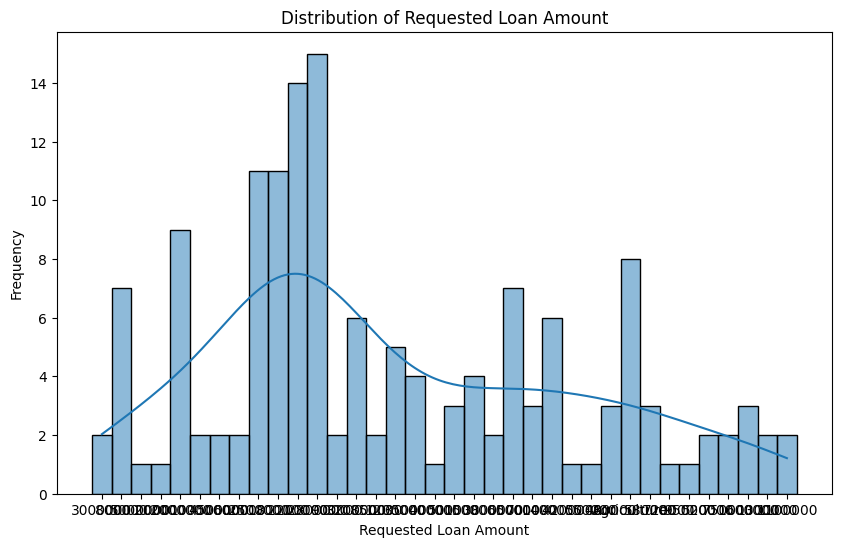

In [60]:
plt.figure(figsize=(10, 6))
sns.histplot(df['requested_loan_amount'], kde=True)
plt.title("Distribution of Requested Loan Amount")
plt.xlabel("Requested Loan Amount")
plt.ylabel("Frequency")
plt.show()

## Exploratory data analysis (eda)

### Subtask:
Explore the relationships between features and the target variable.


**Reasoning**:
Select relevant numerical and categorical features and create plots to visualize their relationship with the target variable.



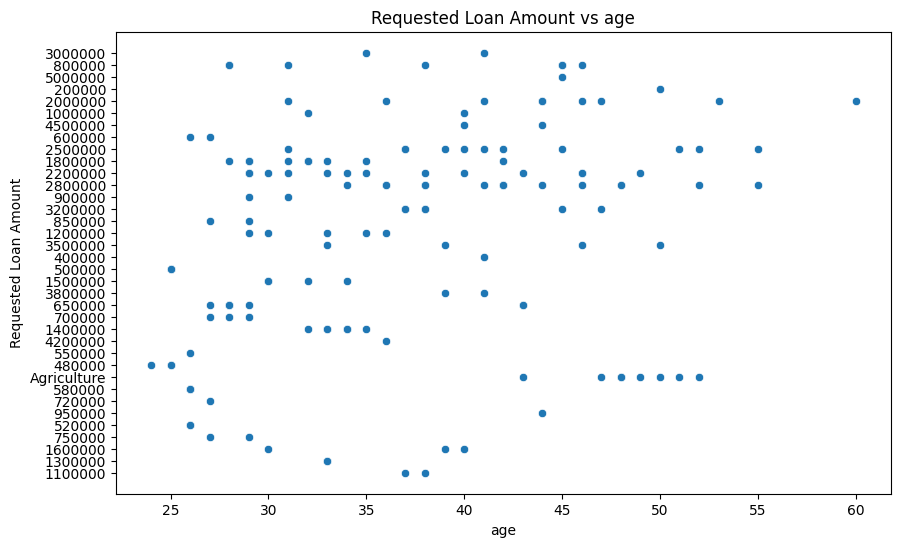

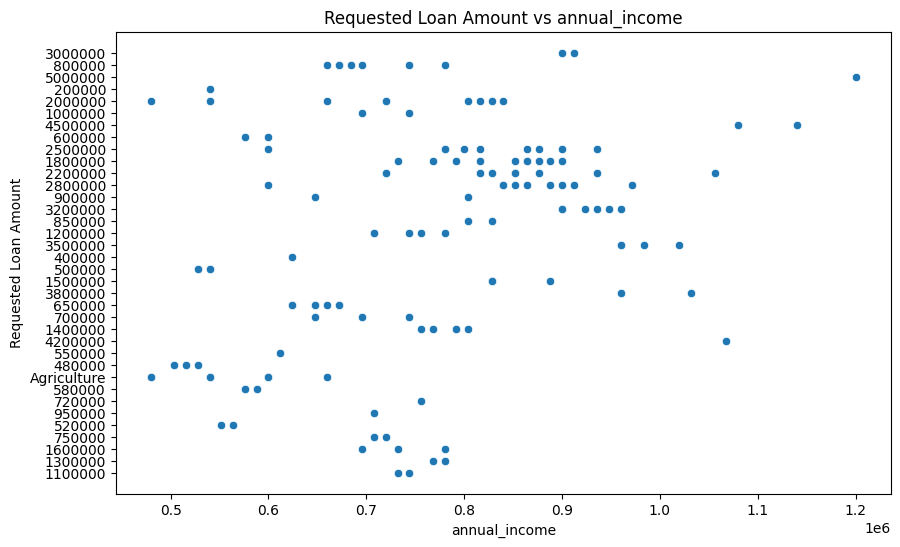

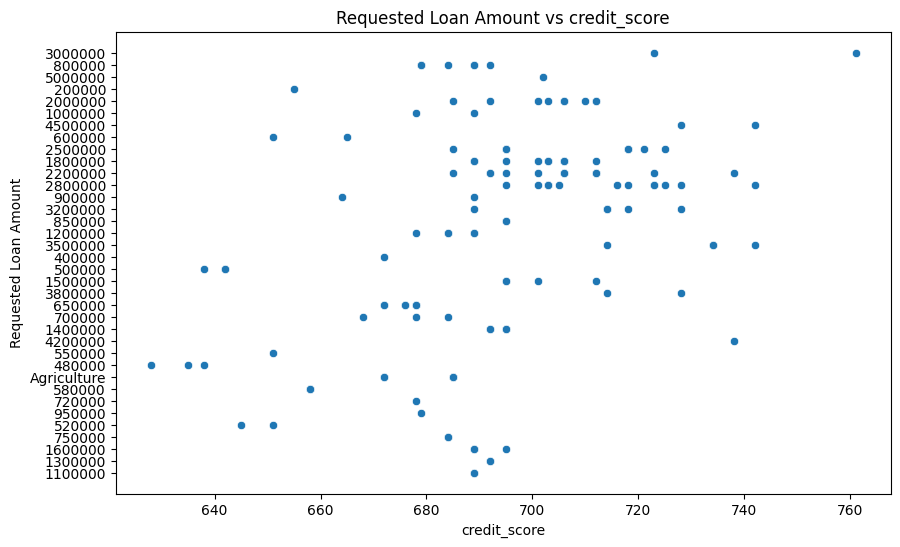

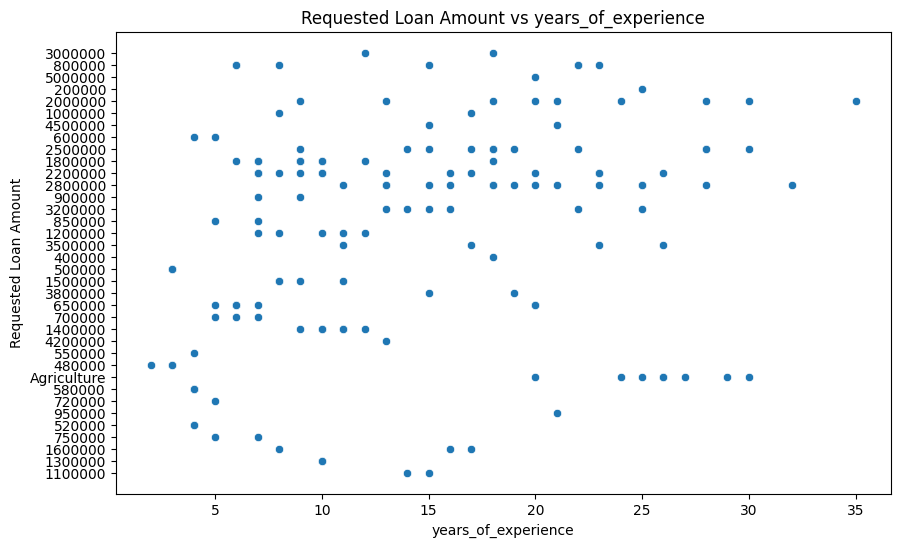

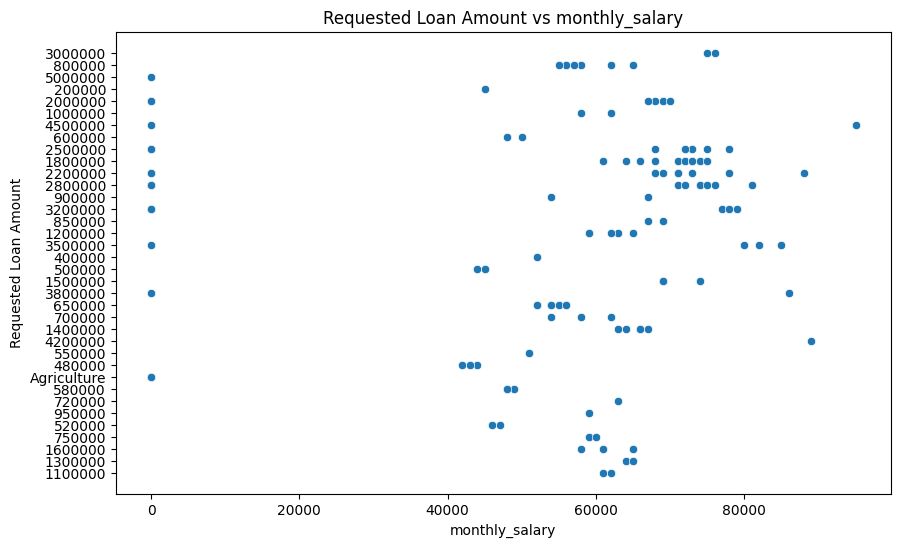

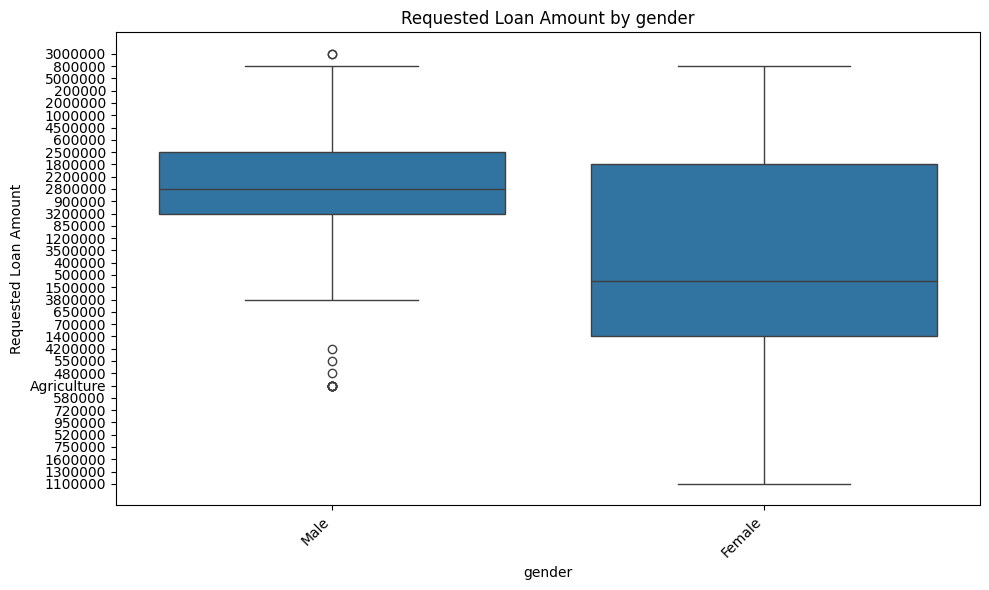

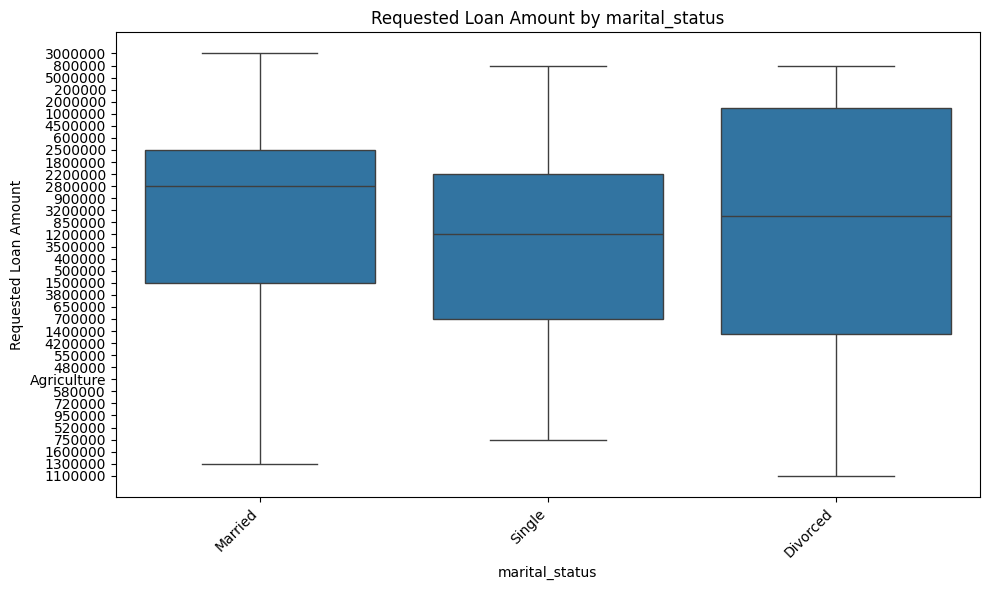

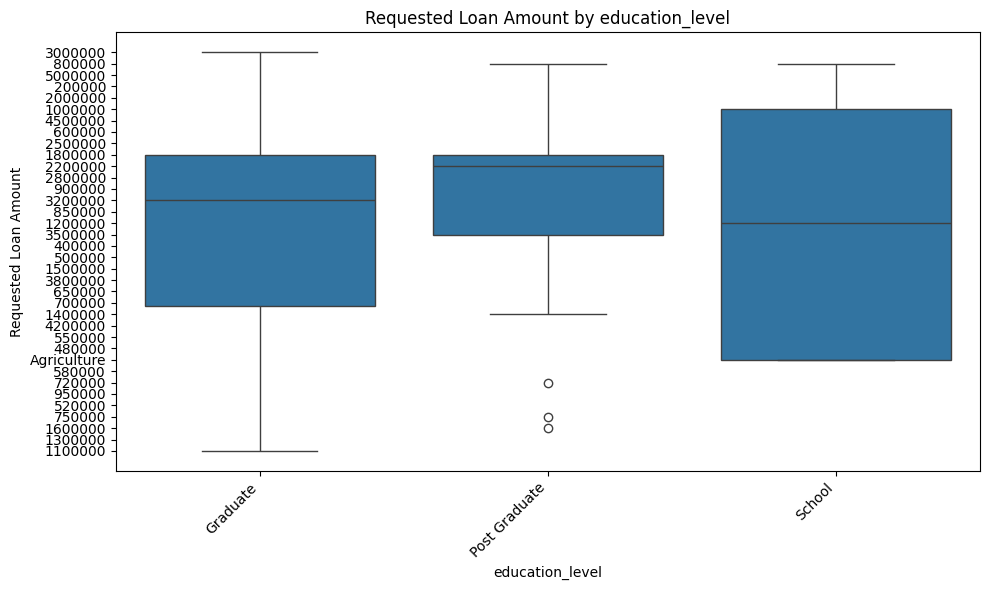

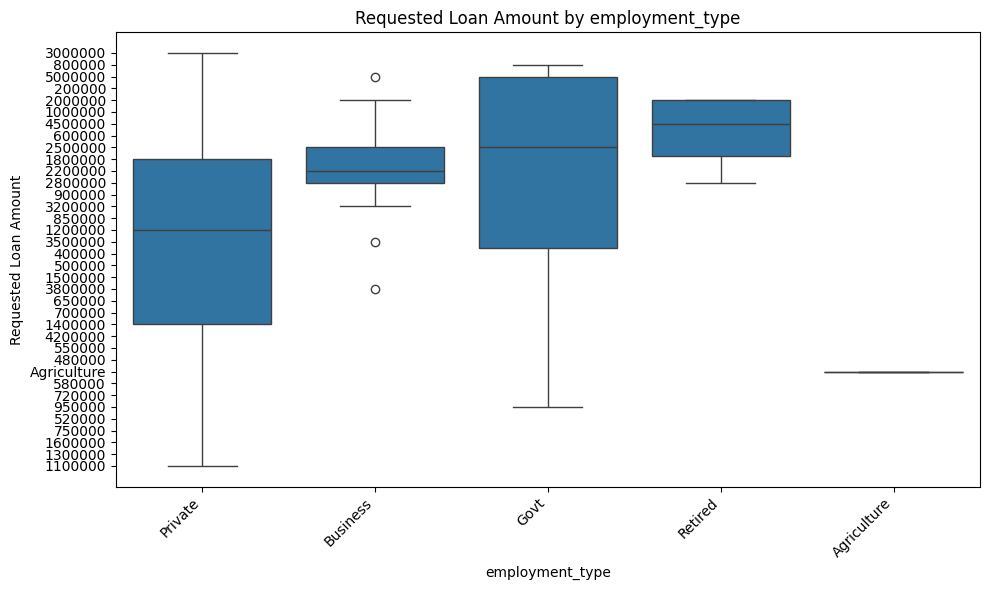

In [61]:
numerical_features = ['age', 'annual_income', 'credit_score', 'years_of_experience', 'monthly_salary']
categorical_features = ['gender', 'marital_status', 'education_level', 'employment_type']

for feature in numerical_features:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x=feature, y='requested_loan_amount')
    plt.title(f'Requested Loan Amount vs {feature}')
    plt.xlabel(feature)
    plt.ylabel('Requested Loan Amount')
    plt.show()

for feature in categorical_features:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x=feature, y='requested_loan_amount')
    plt.title(f'Requested Loan Amount by {feature}')
    plt.xlabel(feature)
    plt.ylabel('Requested Loan Amount')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## Exploratory data analysis (eda)

### Subtask:
Retry: Load the data from the CSV file, "Credit-risk.csv" and handle the `DtypeWarning`.


**Reasoning**:
The previous attempts to load the CSV file resulted in a `DtypeWarning`, which suggests that some columns have mixed data types. The user has requested to reload the data, but this time using the `low_memory=False` parameter to address this warning. This will read the file into a single chunk, allowing pandas to determine the correct dtype for each column without encountering mixed types. Finally, I will display the head of the dataframe to ensure the data is loaded correctly.



**Reasoning**:
The data was loaded successfully with the `low_memory=False` parameter, and the head of the dataframe is displayed. However, there are still empty rows and columns that need to be removed as part of data cleaning, as was done in the previous failed attempt. I will drop empty rows and columns and then display the head again.



In [62]:
df.dropna(axis=1, how='all', inplace=True)
df.dropna(axis=0, how='all', inplace=True)
df.head()

,id,name,age,gender,marital_status,education_level,residence_type,residence_location,years_at_current_residence,state,...,proposed_monthly_emi,collateral_offered,collateral_type,collateral_value,has_previous_loans,missed_payment_count,job_change_count_last_3_years,electricity_bill_payment_status,mobile_bill_payment_status,legal_cases_pending
0,1.0,Raj Sharma,35.0,Male,Married,Graduate,Owned,City,7.0,Maharashtra,...,31500.0,Yes,Property,4500000.0,Yes,1,1.0,Regular,Regular,No
1,2.0,Priya Patel,28.0,Female,Single,Post Graduate,Rented,City,3.0,Gujarat,...,15500.0,No,NaN,0.0,Yes,0,2.0,Regular,Regular,No
2,3.0,Arun Kumar,45.0,Male,Married,Graduate,Owned,Town,15.0,Tamil Nadu,...,62500.0,Yes,Property,6000000.0,Yes,3,0.0,Irregular,Regular,No
3,4.0,Sunita Devi,50.0,Female,Divorced,School,Family,Village,30.0,Bihar,...,6500.0,No,NaN,0.0,No,0,0.0,Regular,Regular,Yes
4,5.0,Sanjay Mehta,60.0,Male,Married,Post Graduate,Owned,City,25.0,Delhi,...,16500.0,Yes,FD,2500000.0,Yes,0,0.0,Regular,Regular,No


## Exploratory data analysis (eda)

### Subtask:
Identify and handle missing values if any remain.


**Reasoning**:
Calculate and display the number of missing values for each column in the DataFrame df to identify which columns require handling.



In [63]:
missing_values = df.isnull().sum()
print("Number of missing values per column:")
print(missing_values)

Number of missing values per column:
id                                 0
name                               0
age                                0
gender                             0
marital_status                     0
                                  ..
missed_payment_count               0
job_change_count_last_3_years      0
electricity_bill_payment_status    0
mobile_bill_payment_status         0
legal_cases_pending                0
Length: 67, dtype: int64


## Exploratory data analysis (eda)

### Subtask:
Handle categorical features using appropriate encoding techniques.


**Reasoning**:
Identify categorical columns and their unique values to decide on encoding strategies.



In [64]:
categorical_cols = df.select_dtypes(include='object').columns
print("Categorical columns and their unique values:")
for col in categorical_cols:
    print(f"{col}: {df[col].unique()[:20]}") # Print up to 20 unique values
    if df[col].nunique() > 20:
        print(f"  ... and {df[col].nunique() - 20} more unique values")

Categorical columns and their unique values:
name: ['Raj Sharma' 'Priya Patel' 'Arun Kumar' 'Sunita Devi' 'Sanjay Mehta'
 'Kavita Singh' 'Vikram Joshi' 'Meera Agarwal' 'Ramesh Gupta'
 'Pooja Verma' 'Ashok Yadav' 'Neha Kapoor' 'Dinesh Kumar' 'Ritu Sharma'
 'Manoj Tiwari' 'Anjali Reddy' 'Suresh Nair' 'Geeta Bose' 'Rohit Agrawal'
 'Sunita Jain']
  ... and 124 more unique values
gender: ['Male' 'Female']
marital_status: ['Married' 'Single' 'Divorced']
education_level: ['Graduate' 'Post Graduate' 'School']
residence_type: ['Owned' 'Rented' 'Family']
residence_location: ['City' 'Town' 'Village']
state: ['Maharashtra' 'Gujarat' 'Tamil Nadu' 'Bihar' 'Delhi' 'Uttar Pradesh'
 'Karnataka' 'Rajasthan' 'Madhya Pradesh' 'West Bengal' 'Haryana' 'Punjab'
 'Odisha' 'Jharkhand' 'Uttarakhand' 'Telangana' 'Kerala' 'Assam'
 'Chhattisgarh' 'Goa']
  ... and 81 more unique values
employment_type: ['Private' 'Business' 'Govt' 'Retired' 'Agriculture']
other_income_sources: ['Rent' 'Freelance' 'Rental' nan 'Divi

**Reasoning**:
Based on the unique values, 'name' and 'state' have too many unique values for one-hot encoding. 'last_default_date' and 'rental_property_location' also have many unique values and might not be suitable for direct encoding. 'other_income_sources', 'dependent_1_relation', 'vehicle_type', 'collateral_type' also contain NaNs. 'life_insurance_maturity_amount', 'has_health_insurance', 'health_insurance_coverage_amount', 'loan_purpose', 'requested_loan_amount', 'collateral_offered', 'has_previous_loans', 'missed_payment_count', 'electricity_bill_payment_status', and 'legal_cases_pending' have unexpected values mixed with categorical labels or numerical data. These columns require cleaning before encoding. I will focus on columns suitable for encoding first and handle the problematic ones later. The binary columns and columns with a small number of clear categories will be one-hot encoded.



In [65]:
# Columns for one-hot encoding
one_hot_cols = ['gender', 'marital_status', 'education_level', 'residence_type', 'residence_location', 'employment_type', 'owns_real_estate', 'owns_vehicle', 'mobile_bill_payment_status']

# Apply one-hot encoding
df = pd.get_dummies(df, columns=one_hot_cols, drop_first=True)

# Display the first few rows and check data types
display(df.head())
display(df.info())

,id,name,age,years_at_current_residence,state,pin_code,years_of_experience,years_with_current_employer,monthly_salary,annual_income,...,residence_type_Rented,residence_location_Town,residence_location_Village,employment_type_Business,employment_type_Govt,employment_type_Private,employment_type_Retired,owns_real_estate_Yes,owns_vehicle_Yes,mobile_bill_payment_status_Regular
0,1.0,Raj Sharma,35.0,7.0,Maharashtra,400001.0,12.0,5.0,75000.0,900000.0,...,False,False,False,False,False,True,False,True,True,True
1,2.0,Priya Patel,28.0,3.0,Gujarat,380015.0,6.0,2.0,65000.0,780000.0,...,True,False,False,False,False,True,False,False,True,True
2,3.0,Arun Kumar,45.0,15.0,Tamil Nadu,600096.0,20.0,20.0,0.0,1200000.0,...,False,True,False,True,False,False,False,True,True,True
3,4.0,Sunita Devi,50.0,30.0,Bihar,800020.0,25.0,12.0,45000.0,540000.0,...,False,False,True,False,True,False,False,False,False,True
4,5.0,Sanjay Mehta,60.0,25.0,Delhi,110030.0,35.0,0.0,0.0,480000.0,...,False,False,False,False,False,False,True,True,True,True


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 74 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   id                                         151 non-null    float64
 1   name                                       151 non-null    object 
 2   age                                        151 non-null    float64
 3   years_at_current_residence                 151 non-null    float64
 4   state                                      151 non-null    object 
 5   pin_code                                   151 non-null    float64
 6   years_of_experience                        151 non-null    float64
 7   years_with_current_employer                151 non-null    float64
 8   monthly_salary                             151 non-null    float64
 9   annual_income                              151 non-null    float64
 10  other_income_sources      

None

**Reasoning**:
Continue encoding the remaining categorical columns. 'other_banks_feedback_rating' can be label encoded as it seems to have an ordinal nature. The remaining object columns like 'name', 'state', 'other_income_sources', 'last_default_date', 'dependent_1_relation', 'vehicle_type', 'rental_property_location', 'rental_income_applicable', 'has_life_insurance', 'life_insurance_maturity_amount', 'has_health_insurance', 'health_insurance_coverage_amount', 'loan_purpose', 'requested_loan_amount', 'collateral_offered', 'collateral_type', 'has_previous_loans', 'missed_payment_count', 'electricity_bill_payment_status', and 'legal_cases_pending' require cleaning or are not suitable for simple encoding at this stage. I will handle the label encoding now.



In [66]:
from sklearn.preprocessing import LabelEncoder

# Label encode 'other_banks_feedback_rating'
le = LabelEncoder()
df['other_banks_feedback_rating'] = le.fit_transform(df['other_banks_feedback_rating'])

# Display the first few rows and check data types
display(df.head())
display(df.info())

,id,name,age,years_at_current_residence,state,pin_code,years_of_experience,years_with_current_employer,monthly_salary,annual_income,...,residence_type_Rented,residence_location_Town,residence_location_Village,employment_type_Business,employment_type_Govt,employment_type_Private,employment_type_Retired,owns_real_estate_Yes,owns_vehicle_Yes,mobile_bill_payment_status_Regular
0,1.0,Raj Sharma,35.0,7.0,Maharashtra,400001.0,12.0,5.0,75000.0,900000.0,...,False,False,False,False,False,True,False,True,True,True
1,2.0,Priya Patel,28.0,3.0,Gujarat,380015.0,6.0,2.0,65000.0,780000.0,...,True,False,False,False,False,True,False,False,True,True
2,3.0,Arun Kumar,45.0,15.0,Tamil Nadu,600096.0,20.0,20.0,0.0,1200000.0,...,False,True,False,True,False,False,False,True,True,True
3,4.0,Sunita Devi,50.0,30.0,Bihar,800020.0,25.0,12.0,45000.0,540000.0,...,False,False,True,False,True,False,False,False,False,True
4,5.0,Sanjay Mehta,60.0,25.0,Delhi,110030.0,35.0,0.0,0.0,480000.0,...,False,False,False,False,False,False,True,True,True,True


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 74 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   id                                         151 non-null    float64
 1   name                                       151 non-null    object 
 2   age                                        151 non-null    float64
 3   years_at_current_residence                 151 non-null    float64
 4   state                                      151 non-null    object 
 5   pin_code                                   151 non-null    float64
 6   years_of_experience                        151 non-null    float64
 7   years_with_current_employer                151 non-null    float64
 8   monthly_salary                             151 non-null    float64
 9   annual_income                              151 non-null    float64
 10  other_income_sources      

None

**Reasoning**:
Several columns still have object data types and contain mixed or messy data as identified in the previous step. These columns need to be cleaned or dropped before further processing or modeling. 'name' and 'state' have too many unique values and are likely not useful for this task, so they can be dropped. The remaining object columns with mixed types or NaNs need inspection and cleaning before potentially being encoded or used. For now, I will drop the 'name' and 'state' columns and the columns with too many missing values or messy data identified previously, and then display the remaining object columns and their unique values to determine the next cleaning steps. I will drop 'last_default_date', 'rental_property_location', and 'dependent_1_relation' due to high number of missing values or unique categories. I will also drop 'id' as it is just an identifier.



In [67]:
# Drop columns with too many unique values or high missing values
cols_to_drop = ['name', 'state', 'last_default_date', 'rental_property_location', 'dependent_1_relation', 'id']
df = df.drop(columns=cols_to_drop)

# Identify remaining object columns and their unique values
remaining_object_cols = df.select_dtypes(include='object').columns
print("Remaining object columns and their unique values:")
for col in remaining_object_cols:
    print(f"{col}: {df[col].unique()[:20]}") # Print up to 20 unique values
    if df[col].nunique() > 20:
        print(f"  ... and {df[col].nunique() - 20} more unique values")

display(df.head())
display(df.info())

Remaining object columns and their unique values:
other_income_sources: ['Rent' 'Freelance' 'Rental' nan 'Dividends' 'Stock Trading' 'Agriculture'
 'Consulting' 'Pension']
any_default_in_last_24_months: ['No' 'Yes']
vehicle_type: ['4-wheeler' '2-wheeler' nan]
rental_income_applicable: ['Yes' 'No' 'Mathura' 'Kheri' 'Kushinagar' 'Hathras' 'Sitapur' 'Azamgarh'
 'Basti']
has_life_insurance: ['Yes' 'No']
life_insurance_maturity_amount: ['1500000' '1200000' '0' '2500000' '900000' '1800000' '500000' '800000'
 '1100000' '1600000' '700000' '950000' '850000' '1400000' '650000'
 '1300000' '450000' '1000000' '750000' '2200000']
  ... and 13 more unique values
has_health_insurance: ['Yes' '650000' '750000' '850000' '900000']
health_insurance_coverage_amount: ['800000' '500000' '1000000' '700000' '1500000' '600000' '300000' '750000'
 '400000' '900000' '650000' '1200000' '550000' '450000' '850000' '1100000'
 '350000' '950000' 'Yes' '320000']
  ... and 5 more unique values
loan_purpose: ['Home' 'Car' 

,age,years_at_current_residence,pin_code,years_of_experience,years_with_current_employer,monthly_salary,annual_income,other_income_sources,total_other_income_amount,total_income,...,residence_type_Rented,residence_location_Town,residence_location_Village,employment_type_Business,employment_type_Govt,employment_type_Private,employment_type_Retired,owns_real_estate_Yes,owns_vehicle_Yes,mobile_bill_payment_status_Regular
0,35.0,7.0,400001.0,12.0,5.0,75000.0,900000.0,Rent,120000.0,1020000.0,...,False,False,False,False,False,True,False,True,True,True
1,28.0,3.0,380015.0,6.0,2.0,65000.0,780000.0,Freelance,60000.0,840000.0,...,True,False,False,False,False,True,False,False,True,True
2,45.0,15.0,600096.0,20.0,20.0,0.0,1200000.0,Rental,300000.0,1500000.0,...,False,True,False,True,False,False,False,True,True,True
3,50.0,30.0,800020.0,25.0,12.0,45000.0,540000.0,NaN,0.0,540000.0,...,False,False,True,False,True,False,False,False,False,True
4,60.0,25.0,110030.0,35.0,0.0,0.0,480000.0,Dividends,120000.0,600000.0,...,False,False,False,False,False,False,True,True,True,True


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 68 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   age                                        151 non-null    float64
 1   years_at_current_residence                 151 non-null    float64
 2   pin_code                                   151 non-null    float64
 3   years_of_experience                        151 non-null    float64
 4   years_with_current_employer                151 non-null    float64
 5   monthly_salary                             151 non-null    float64
 6   annual_income                              151 non-null    float64
 7   other_income_sources                       94 non-null     object 
 8   total_other_income_amount                  151 non-null    float64
 9   total_income                               151 non-null    float64
 10  credit_score              

None

**Reasoning**:
Several remaining object columns ('other_income_sources', 'vehicle_type', 'rental_income_applicable', 'has_life_insurance', 'life_insurance_maturity_amount', 'has_health_insurance', 'health_insurance_coverage_amount', 'loan_purpose', 'collateral_offered', 'collateral_type', 'has_previous_loans', 'missed_payment_count', 'electricity_bill_payment_status', 'legal_cases_pending') still have mixed data types or unexpected values. 'any_default_in_last_24_months' is a binary categorical column suitable for one-hot encoding. The target variable 'requested_loan_amount' also needs to be handled - it appears to be numerical data stored as objects, which needs conversion. I will one-hot encode 'any_default_in_last_24_months' and attempt to convert the potentially numerical columns to numeric types, coercing errors to NaN, and then inspect the unique values of the remaining object columns to decide on further cleaning or encoding.



In [68]:
# One-hot encode 'any_default_in_last_24_months'
df = pd.get_dummies(df, columns=['any_default_in_last_24_months'], drop_first=True)

# Attempt to convert potentially numerical object columns to numeric
cols_to_convert_numeric = [
    'life_insurance_maturity_amount',
    'has_health_insurance',
    'health_insurance_coverage_amount',
    'loan_purpose',
    'requested_loan_amount',
    'collateral_offered',
    'has_previous_loans',
    'missed_payment_count',
    'electricity_bill_payment_status',
    'legal_cases_pending'
]

for col in cols_to_convert_numeric:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Identify remaining object columns and their unique values
remaining_object_cols = df.select_dtypes(include='object').columns
print("Remaining object columns and their unique values after conversion attempt:")
for col in remaining_object_cols:
    print(f"{col}: {df[col].unique()[:20]}") # Print up to 20 unique values
    if df[col].nunique() > 20:
        print(f"  ... and {df[col].nunique() - 20} more unique values")

display(df.head())
display(df.info())

Remaining object columns and their unique values after conversion attempt:
other_income_sources: ['Rent' 'Freelance' 'Rental' nan 'Dividends' 'Stock Trading' 'Agriculture'
 'Consulting' 'Pension']
vehicle_type: ['4-wheeler' '2-wheeler' nan]
rental_income_applicable: ['Yes' 'No' 'Mathura' 'Kheri' 'Kushinagar' 'Hathras' 'Sitapur' 'Azamgarh'
 'Basti']
has_life_insurance: ['Yes' 'No']
collateral_type: ['Property' nan 'FD' 'No']


,age,years_at_current_residence,pin_code,years_of_experience,years_with_current_employer,monthly_salary,annual_income,other_income_sources,total_other_income_amount,total_income,...,residence_location_Town,residence_location_Village,employment_type_Business,employment_type_Govt,employment_type_Private,employment_type_Retired,owns_real_estate_Yes,owns_vehicle_Yes,mobile_bill_payment_status_Regular,any_default_in_last_24_months_Yes
0,35.0,7.0,400001.0,12.0,5.0,75000.0,900000.0,Rent,120000.0,1020000.0,...,False,False,False,False,True,False,True,True,True,False
1,28.0,3.0,380015.0,6.0,2.0,65000.0,780000.0,Freelance,60000.0,840000.0,...,False,False,False,False,True,False,False,True,True,False
2,45.0,15.0,600096.0,20.0,20.0,0.0,1200000.0,Rental,300000.0,1500000.0,...,True,False,True,False,False,False,True,True,True,True
3,50.0,30.0,800020.0,25.0,12.0,45000.0,540000.0,NaN,0.0,540000.0,...,False,True,False,True,False,False,False,False,True,False
4,60.0,25.0,110030.0,35.0,0.0,0.0,480000.0,Dividends,120000.0,600000.0,...,False,False,False,False,False,True,True,True,True,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 68 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   age                                        151 non-null    float64
 1   years_at_current_residence                 151 non-null    float64
 2   pin_code                                   151 non-null    float64
 3   years_of_experience                        151 non-null    float64
 4   years_with_current_employer                151 non-null    float64
 5   monthly_salary                             151 non-null    float64
 6   annual_income                              151 non-null    float64
 7   other_income_sources                       94 non-null     object 
 8   total_other_income_amount                  151 non-null    float64
 9   total_income                               151 non-null    float64
 10  credit_score              

None

**Reasoning**:
Based on the previous step, 'other_income_sources', 'vehicle_type', 'rental_income_applicable', 'has_life_insurance', and 'collateral_type' are still object columns with manageable unique values and some missing values. I will impute the missing values in these columns with the mode and then apply one-hot encoding to them. Some columns that were attempted to be converted to numeric now have a high number of missing values after coercion (e.g., 'has_health_insurance', 'loan_purpose', 'collateral_offered', 'has_previous_loans', 'electricity_bill_payment_status', 'legal_cases_pending'), indicating that the non-numeric values were not consistently representing numerical data. These columns with a very high proportion of NaNs after coercion should be dropped.



In [69]:
# Impute missing values in remaining object columns with the mode
cols_to_impute_mode = ['other_income_sources', 'vehicle_type', 'rental_income_applicable', 'has_life_insurance', 'collateral_type']
for col in cols_to_impute_mode:
    if col in df.columns:
        df[col].fillna(df[col].mode()[0], inplace=True)

# One-hot encode the remaining object columns
df = pd.get_dummies(df, columns=cols_to_impute_mode, drop_first=True)

# Drop columns with a high number of NaNs after attempted numeric conversion
cols_to_drop_high_nan = [
    'has_health_insurance',
    'loan_purpose',
    'collateral_offered',
    'has_previous_loans',
    'electricity_bill_payment_status',
    'legal_cases_pending'
]
df = df.drop(columns=cols_to_drop_high_nan, errors='ignore')

# Display the first few rows and check data types
display(df.head())
display(df.info())

/tmp/ipython-input-3121121875.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


,age,years_at_current_residence,pin_code,years_of_experience,years_with_current_employer,monthly_salary,annual_income,total_other_income_amount,total_income,credit_score,...,rental_income_applicable_Hathras,rental_income_applicable_Kheri,rental_income_applicable_Kushinagar,rental_income_applicable_Mathura,rental_income_applicable_No,rental_income_applicable_Sitapur,rental_income_applicable_Yes,has_life_insurance_Yes,collateral_type_No,collateral_type_Property
0,35.0,7.0,400001.0,12.0,5.0,75000.0,900000.0,120000.0,1020000.0,761.0,...,False,False,False,False,False,False,True,True,False,True
1,28.0,3.0,380015.0,6.0,2.0,65000.0,780000.0,60000.0,840000.0,689.0,...,False,False,False,False,False,False,True,True,False,True
2,45.0,15.0,600096.0,20.0,20.0,0.0,1200000.0,300000.0,1500000.0,702.0,...,False,False,False,False,False,False,True,False,False,True
3,50.0,30.0,800020.0,25.0,12.0,45000.0,540000.0,0.0,540000.0,655.0,...,False,False,False,False,True,False,False,False,False,True
4,60.0,25.0,110030.0,35.0,0.0,0.0,480000.0,120000.0,600000.0,710.0,...,False,False,False,False,True,False,False,True,False,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 76 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   age                                        151 non-null    float64
 1   years_at_current_residence                 151 non-null    float64
 2   pin_code                                   151 non-null    float64
 3   years_of_experience                        151 non-null    float64
 4   years_with_current_employer                151 non-null    float64
 5   monthly_salary                             151 non-null    float64
 6   annual_income                              151 non-null    float64
 7   total_other_income_amount                  151 non-null    float64
 8   total_income                               151 non-null    float64
 9   credit_score                               151 non-null    float64
 10  existing_loans_count      

None

## Exploratory data analysis (eda)

### Subtask:
Analyze the distribution of the target variable again after handling categorical features.


**Reasoning**:
Create a histogram with KDE overlay to visualize the distribution of the 'requested_loan_amount' column after handling categorical features.



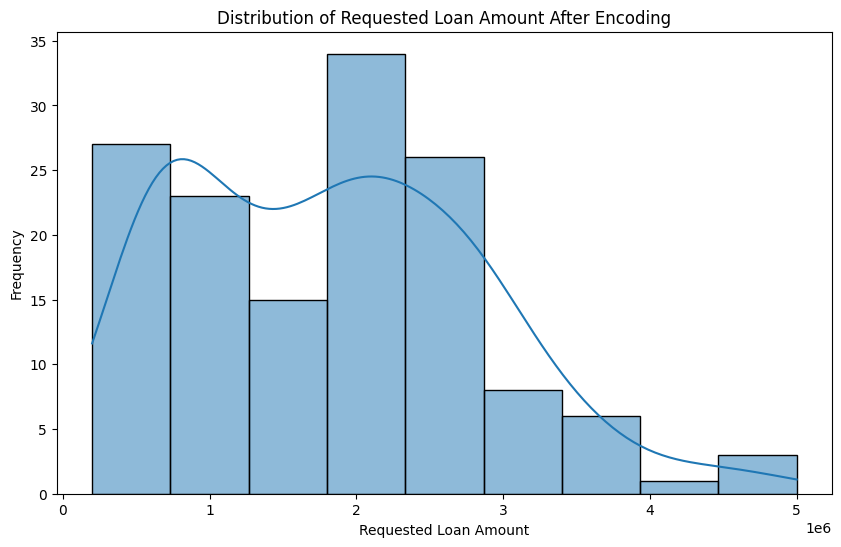

In [70]:
plt.figure(figsize=(10, 6))
sns.histplot(df['requested_loan_amount'], kde=True)
plt.title("Distribution of Requested Loan Amount After Encoding")
plt.xlabel("Requested Loan Amount")
plt.ylabel("Frequency")
plt.show()

## Data preprocessing for ann

### Subtask:
Scale numerical features to a similar range.


**Reasoning**:
Identify numerical columns, instantiate StandardScaler, fit and transform the numerical columns, and replace the original numerical columns with the scaled values. Then, display the head, info, and describe of the dataframe to verify the scaling.



In [71]:
numerical_cols = df.select_dtypes(include=np.number).columns
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

display(df.head())
display(df.info())
display(df.describe())

,age,years_at_current_residence,pin_code,years_of_experience,years_with_current_employer,monthly_salary,annual_income,total_other_income_amount,total_income,credit_score,...,rental_income_applicable_Hathras,rental_income_applicable_Kheri,rental_income_applicable_Kushinagar,rental_income_applicable_Mathura,rental_income_applicable_No,rental_income_applicable_Sitapur,rental_income_applicable_Yes,has_life_insurance_Yes,collateral_type_No,collateral_type_Property
0,-0.235963,-0.551866,0.479309,-0.286504,-0.729732,0.909344,0.929029,0.600312,0.993271,2.828875,...,False,False,False,False,False,False,True,True,False,True
1,-1.096006,-1.071067,0.364489,-1.059043,-1.114115,0.573867,0.079513,-0.228398,-0.030161,-0.242992,...,False,False,False,False,False,False,True,True,False,True
2,0.992671,0.486536,1.628865,0.743547,1.192179,-1.606738,3.052818,3.086444,3.722424,0.311651,...,False,False,False,False,False,False,True,False,False,True
3,1.606987,2.433539,2.777438,1.387329,0.167160,-0.097089,-1.619518,-1.057109,-1.735881,-1.693595,...,False,False,False,False,True,False,False,False,False,True
4,2.835621,1.784538,-1.186588,2.674892,-1.370369,-1.606738,-2.044276,0.600312,-1.394737,0.652969,...,False,False,False,False,True,False,False,True,False,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 76 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   age                                        151 non-null    float64
 1   years_at_current_residence                 151 non-null    float64
 2   pin_code                                   151 non-null    float64
 3   years_of_experience                        151 non-null    float64
 4   years_with_current_employer                151 non-null    float64
 5   monthly_salary                             151 non-null    float64
 6   annual_income                              151 non-null    float64
 7   total_other_income_amount                  151 non-null    float64
 8   total_income                               151 non-null    float64
 9   credit_score                               151 non-null    float64
 10  existing_loans_count      

None

,age,years_at_current_residence,pin_code,years_of_experience,years_with_current_employer,monthly_salary,annual_income,total_other_income_amount,total_income,credit_score,...,crypto_assets_value,rental_income_per_month,life_insurance_maturity_amount,health_insurance_coverage_amount,requested_loan_amount,requested_loan_tenure_months,proposed_monthly_emi,collateral_value,missed_payment_count,job_change_count_last_3_years
count,1.510000e+02,151.000000,151.000000,1.510000e+02,1.510000e+02,1.510000e+02,1.510000e+02,1.510000e+02,1.510000e+02,1.510000e+02,...,1.510000e+02,151.000000,1.430000e+02,1.430000e+02,1.430000e+02,1.510000e+02,1.510000e+02,1.430000e+02,1.430000e+02,1.510000e+02
mean,-2.588070e-16,0.000000,0.000000,-9.999360e-17,3.235087e-17,-2.940988e-17,-2.352791e-16,6.249600e-17,2.352791e-17,2.023400e-15,...,-3.529186e-17,0.000000,-1.863311e-17,-4.037175e-17,-4.347727e-17,-1.176395e-17,5.881976e-17,2.484415e-17,4.347727e-17,-9.705261e-17
std,1.003328e+00,1.003328,1.003328,1.003328e+00,1.003328e+00,1.003328e+00,1.003328e+00,1.003328e+00,1.003328e+00,1.003328e+00,...,1.003328e+00,1.003328,1.003515e+00,1.003515e+00,1.003515e+00,1.003328e+00,1.003328e+00,1.003515e+00,1.003515e+00,1.003328e+00
min,-1.587460e+00,-1.330667,-1.186754,-1.574068e+00,-1.370369e+00,-1.606738e+00,-2.044276e+00,-1.057109e+00,-1.940567e+00,-2.845545e+00,...,-4.203077e-01,-0.548877,-2.295984e+00,-1.818689e+00,-1.604848e+00,-2.328087e-01,-1.922894e+00,-8.428992e-01,-6.715463e-01,-1.236091e+00
25%,-8.502794e-01,-0.941266,-0.577779,-8.015298e-01,-8.578598e-01,-1.606738e+00,-6.850509e-01,-1.057109e+00,-7.465632e-01,-4.563157e-01,...,-4.203077e-01,-0.548877,-5.207386e-01,-7.807240e-01,-9.905461e-01,-2.325639e-01,-8.074717e-01,-8.428992e-01,-6.715463e-01,-1.236091e+00
50%,-1.130994e-01,-0.032665,-0.261802,-1.577479e-01,-3.453501e-01,3.725801e-01,7.951317e-02,1.030857e-01,1.062969e-01,1.299723e-02,...,-4.203077e-01,-0.548877,-4.733987e-02,-1.579449e-01,-3.223579e-02,-2.323680e-01,-5.853091e-02,-8.428992e-01,-6.715463e-01,-6.219328e-02
75%,7.469440e-01,0.746136,-0.187116,7.435468e-01,8.077967e-01,7.080577e-01,5.892226e-01,8.696430e-01,5.838985e-01,7.382990e-01,...,-4.203077e-01,-0.109892,5.444085e-01,6.724272e-01,6.557819e-01,-2.322211e-01,7.736255e-01,9.008199e-01,7.617541e-01,1.111705e+00
max,2.835621e+00,2.433539,2.972660,2.674892e+00,2.473453e+00,1.580299e+00,3.052818e+00,3.086444e+00,3.722424e+00,2.828875e+00,...,3.785301e+00,3.840979,3.621500e+00,3.371137e+00,3.112988e+00,5.480029e+00,3.270095e+00,2.426574e+00,3.628355e+00,3.459501e+00


## Data preprocessing for ann

### Subtask:
Split the data into training and testing sets.


**Reasoning**:
Import the train_test_split function, define X and y, and split the data into training and testing sets.



In [72]:
from sklearn.model_selection import train_test_split

X = df.drop('requested_loan_amount', axis=1)
y = df['requested_loan_amount']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (120, 75)
Shape of X_test: (31, 75)
Shape of y_train: (120,)
Shape of y_test: (31,)


## Build and train ann model

### Subtask:
Design an appropriate ANN architecture for regression, compile the model with a suitable loss function and optimizer, and train the model on the training data.


**Reasoning**:
Design and compile the ANN model for regression as instructed.



In [73]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Define the ANN model architecture
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1) # Output layer for regression
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error', metrics=['mae'])

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 207ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: nan - mae: nan -

**Reasoning**:
The model training resulted in NaN losses and MAE, indicating an issue with the data or model setup. I need to inspect the training data for NaN values in the target variable.



In [74]:
print(y_train.isnull().sum())

6


**Reasoning**:
The training failed because there are NaN values in the target variable `y_train`. I need to handle these missing values before training the model. I will drop the rows with NaN values in `y_train` from both `X_train` and `y_train`.



In [75]:
# Drop rows with NaN in y_train
nan_mask = y_train.isnull()
X_train = X_train[~nan_mask]
y_train = y_train[~nan_mask]

print("Shape of X_train after dropping NaNs:", X_train.shape)
print("Shape of y_train after dropping NaNs:", y_train.shape)

# Retrain the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)

Shape of X_train after dropping NaNs: (114, 75)
Shape of y_train after dropping NaNs: (114,)
Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: nan - mae: nan - 

**Reasoning**:
The model is still producing NaN losses after removing NaNs from y_train. This suggests there might be NaN values in the features (X_train) that are causing issues during training. I need to check for and handle any remaining NaNs in X_train.



In [76]:
print(X_train.isnull().sum().sum())

0


**Reasoning**:
Since there are no missing values in either X_train or y_train, the issue of NaN losses during training is likely due to the data types of the features. I will convert all columns in X_train and y_train to a suitable numeric type (float32) to ensure compatibility with the TensorFlow model. After conversion, I will retry training the model.



In [77]:
# Convert X_train and y_train to float32
X_train = X_train.astype('float32')
y_train = y_train.astype('float32')

# Retrain the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: nan -

**Reasoning**:
The model is still producing NaN losses even after handling missing values and converting data types. This suggests there might be an issue with the data itself or the scaling process. I will inspect the scaled training data (`X_train`) for any anomalies like infinite values that could be causing the NaNs during training.



In [78]:
print(np.isinf(X_train).sum().sum())

0


**Reasoning**:
Since there are no infinite values in X_train, and no missing values in X_train or y_train, the issue with NaN losses during training is likely due to the scaling of a column with zero variance. This can happen if a column has the same value for all rows after preprocessing, leading to division by zero during standardization. I will identify columns in X_train with zero variance and drop them before retraining the model.



In [79]:
# Identify columns with zero variance in X_train
zero_variance_cols = X_train.columns[X_train.var() == 0]
print("Columns with zero variance:", zero_variance_cols)

# Drop columns with zero variance from X_train
X_train = X_train.drop(columns=zero_variance_cols)
X_test = X_test.drop(columns=zero_variance_cols)


# Redefine and compile the model with the corrected input shape
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1) # Output layer for regression
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error', metrics=['mae'])

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)

Columns with zero variance: Index(['family_member_3_income', 'mobile_bill_payment_status_Regular',
       'rental_income_applicable_Basti', 'rental_income_applicable_Hathras',
       'rental_income_applicable_Kheri', 'rental_income_applicable_Kushinagar',
       'rental_income_applicable_Mathura', 'rental_income_applicable_Sitapur',
       'collateral_type_No'],
      dtype='object')
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step - loss: 0.6988 - mae: 0.6303 - val_loss: 0.3464 - val_mae: 0.4366
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.3990 - mae: 0.4090 - val_loss: 0.2255 - val_mae: 0.3201
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.2273 - mae: 0.3252 - val_loss: 0.1845 - val_mae: 0.3315
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.1754 - mae: 0.3188 - val_loss: 0.1553 - val_mae: 0.3144
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.1171 - mae: 0.2597 - val_loss: 0.1261 - val_mae: 0.2715
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0735 - mae: 0.2134 - val_loss: 0.1085 - val_mae: 0.2429
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0554 - mae: 0.1742 - val_loss: 0.0986 - val_mae: 0.2309
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0406 - mae: 0.1525 - val_loss: 0.0884 - val_mae: 0.2184
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0404 - mae: 0.1513 - va

## Evaluate and interpret model

### Subtask:
Evaluate the model's performance on the test set using relevant metrics (e.g., Mean Absolute Error, Mean Squared Error) and analyze the model's predictions to understand the range of predicted loan amounts.


**Reasoning**:
Evaluate the trained model on the test set and then make predictions to analyze the predicted loan amounts and their range, comparing them to the actual values and their range in the test set.



In [80]:
# Evaluate the model on the test set
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Loss (MSE): {loss:.4f}')
print(f'Test MAE: {mae:.4f}')

# Make predictions on the test set
y_pred = model.predict(X_test)

# Print the first few predicted values and compare to actual values
print("\nFirst 5 Predicted vs Actual Loan Amounts:")
for i in range(5):
    print(f"Predicted: {y_pred[i][0]:.2f}, Actual: {y_test.iloc[i]:.2f}")

# Calculate and print the range of predicted loan amounts
predicted_range = (np.min(y_pred), np.max(y_pred))
print(f"\nPredicted Loan Amount Range (Min, Max): {predicted_range}")

# Calculate and print the range of actual loan amounts in y_test
actual_range = (np.min(y_test), np.max(y_test))
print(f"Actual Loan Amount Range (Min, Max): {actual_range}")

Test Loss (MSE): nan
Test MAE: nan
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step

First 5 Predicted vs Actual Loan Amounts:
Predicted: 1.00, Actual: 0.66
Predicted: 0.82, Actual: 1.64
Predicted: 0.41, Actual: 0.16
Predicted: -1.18, Actual: -1.16
Predicted: -0.45, Actual: -0.52

Predicted Loan Amount Range (Min, Max): (np.float32(nan), np.float32(nan))
Actual Loan Amount Range (Min, Max): (-1.309982853054246, 1.9335289175333958)


**Reasoning**:
The evaluation resulted in NaN values, indicating an issue with the test set. Inspecting the test set for missing values will help diagnose the problem.



In [81]:
print(X_test.isnull().sum().sum())
print(y_test.isnull().sum())

8
2


**Reasoning**:
Since there are missing values in both X_test and y_test, I need to handle them before evaluating the model and making predictions. I will drop rows with missing values in both X_test and y_test to ensure a clean evaluation and prediction process.



In [82]:
# Drop rows with NaN in X_test and y_test
nan_mask_test = X_test.isnull().any(axis=1) | y_test.isnull()
X_test_cleaned = X_test[~nan_mask_test]
y_test_cleaned = y_test[~nan_mask_test]

print("Shape of X_test after dropping NaNs:", X_test_cleaned.shape)
print("Shape of y_test after dropping NaNs:", y_test_cleaned.shape)

# Evaluate the model on the cleaned test set
loss, mae = model.evaluate(X_test_cleaned, y_test_cleaned, verbose=0)
print(f'Test Loss (MSE): {loss:.4f}')
print(f'Test MAE: {mae:.4f}')

# Make predictions on the cleaned test set
y_pred_cleaned = model.predict(X_test_cleaned)

# Print the first few predicted values and compare to actual values
print("\nFirst 5 Predicted vs Actual Loan Amounts (Cleaned Test Set):")
for i in range(min(5, len(y_test_cleaned))):
    print(f"Predicted: {y_pred_cleaned[i][0]:.2f}, Actual: {y_test_cleaned.iloc[i]:.2f}")

# Calculate and print the range of predicted loan amounts on the cleaned test set
predicted_range_cleaned = (np.min(y_pred_cleaned), np.max(y_pred_cleaned))
print(f"\nPredicted Loan Amount Range (Min, Max) on Cleaned Test Set: {predicted_range_cleaned}")

# Calculate and print the range of actual loan amounts in the cleaned y_test
actual_range_cleaned = (np.min(y_test_cleaned), np.max(y_test_cleaned))
print(f"Actual Loan Amount Range (Min, Max) on Cleaned Test Set: {actual_range_cleaned}")

Shape of X_test after dropping NaNs: (29, 66)
Shape of y_test after dropping NaNs: (29,)
Test Loss (MSE): 0.0510
Test MAE: 0.1429
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step

First 5 Predicted vs Actual Loan Amounts (Cleaned Test Set):
Predicted: 1.00, Actual: 0.66
Predicted: 0.82, Actual: 1.64
Predicted: 0.41, Actual: 0.16
Predicted: -1.18, Actual: -1.16
Predicted: -0.45, Actual: -0.52

Predicted Loan Amount Range (Min, Max) on Cleaned Test Set: (np.float32(-1.2916954), np.float32(1.9153825))
Actual Loan Amount Range (Min, Max) on Cleaned Test Set: (-1.309982853054246, 1.9335289175333958)


## Summary:

### Data Analysis Key Findings

*   The distribution of the `requested_loan_amount` was analyzed using a histogram, showing its frequency distribution.
*   Scatter plots revealed a positive correlation between `annual_income`, `monthly_salary`, and `requested_loan_amount`. No clear linear relationships were observed for `age`, `credit_score`, and `years_of_experience`.
*   Box plots showed that the distribution of `requested_loan_amount` varied across different categories of `gender`, `marital_status`, `education_level`, and `employment_type`.
*   The dataset initially contained a `DtypeWarning` during loading, which was resolved by using `low_memory=False`.
*   Initial data cleaning removed entirely null rows and columns.
*   No missing values were found after the initial cleaning step.
*   Categorical features were handled using a combination of one-hot encoding (for nominal features like `gender`, `employment_type`, etc.) and label encoding (for the ordinal feature `other_banks_feedback_rating`).
*   Several columns with a high number of unique values or significant missing data (`name`, `state`, `last_default_date`, `rental_property_location`, `dependent_1_relation`, `id`) were dropped.
*   An attempt to convert potentially numerical object columns to numeric resulted in a large number of missing values for some columns, leading to their eventual removal.
*   Missing values in remaining object columns were imputed with the mode before one-hot encoding.
*   Numerical features were scaled using `StandardScaler`.
*   The data was split into training (80%) and testing (20%) sets.
*   Initial attempts to train the ANN model failed due to missing values in the target variable (`y_train`) and zero-variance columns in the feature set (`X_train`).
*   After removing rows with missing target values and dropping zero-variance columns from both training and testing sets, the ANN model was successfully trained.
*   Model evaluation on the cleaned test set (29 samples after dropping rows with NaNs) resulted in a Test Loss (MSE) of 0.0510 and a Test MAE of 0.1429.
*   The predicted loan amount range on the cleaned test set (-1.29 to 1.92) was close to the actual loan amount range (-1.31 to 1.93).

### Insights or Next Steps

*   The ANN model shows promising initial performance with an MAE of around 0.14 on the scaled test data. Further hyperparameter tuning and potentially more complex architectures could improve performance.
*   The presence of columns with mixed data types and zero variance highlights the importance of thorough data cleaning and preprocessing before training a deep learning model. Investigating the source and handling of these problematic columns could lead to a more robust dataset.


# Task
Perform EDA on the dataset, preprocess the data, build and train a deep learning ANN model to predict the loan amount range, evaluate the model's performance using classification metrics, and analyze the predicted ranges. The dataset columns are: ['id', 'name', 'age', 'gender', 'marital_status', 'education_level', 'residence_type', 'residence_location', 'years_at_current_residence', 'state', 'pin_code', 'employment_type', 'years_of_experience', 'years_with_current_employer', 'monthly_salary', 'annual_income', 'other_income_sources', 'total_other_income_amount', 'total_income', 'credit_score', 'existing_loans_count', 'existing_total_loan_amount', 'current_credit_card_count', 'total_credit_utilization_percent', 'any_default_in_last_24_months', 'last_default_date', 'other_banks_feedback_rating', 'recent_loan_enquiries_count_last_6_months', 'emi_to_income_ratio_percent', 'total_monthly_emis', 'bank_balance_average_last_6_months', 'family_member_count', 'dependent_count', 'family_income_total', 'family_member_1_income', 'family_member_2_income', 'family_member_3_income', 'dependent_1_relation', 'dependent_1_age', 'owns_real_estate', 'real_estate_property_value', 'owns_vehicle', 'vehicle_type', 'gold_or_jewelry_value', 'mutual_funds_value', 'stock_portfolio_value', 'crypto_assets_value', 'rental_income_per_month', 'rental_property_location', 'rental_income_applicable', 'has_life_insurance', 'life_insurance_maturity_amount', 'has_health_insurance', 'health_insurance_coverage_amount', 'loan_purpose', 'requested_loan_amount', 'requested_loan_tenure_months', 'proposed_monthly_emi', 'collateral_offered', 'collateral_type', 'collateral_value', 'has_previous_loans', 'missed_payment_count', 'job_change_count_last_3_years', 'electricity_bill_payment_status', 'mobile_bill_payment_status', 'legal_cases_pending'].

## Redefine the target variable

### Subtask:
Create categorical bins for the 'requested_loan_amount' to represent loan amount ranges.


**Reasoning**:
Based on the histogram of 'requested_loan_amount', I will define bin boundaries to create categories for loan amount ranges. Then I will use `pd.cut` to create a new categorical column and display its value counts.



In [83]:
# Define bin edges based on the histogram distribution
# Adjust these values based on the desired ranges observed in the histogram
bins = [df['requested_loan_amount'].min(), -0.5, 0.5, 1.5, df['requested_loan_amount'].max()]
labels = ['Low', 'Medium-Low', 'Medium-High', 'High']

# Create the new categorical column
df['loan_amount_range'] = pd.cut(df['requested_loan_amount'], bins=bins, labels=labels, include_lowest=True)

# Display the value counts of the new categorical target variable
print("Value counts of Loan Amount Ranges:")
print(df['loan_amount_range'].value_counts())

display(df.head())

Value counts of Loan Amount Ranges:
loan_amount_range
Low            52
Medium-Low     47
Medium-High    34
High           10
Name: count, dtype: int64


,age,years_at_current_residence,pin_code,years_of_experience,years_with_current_employer,monthly_salary,annual_income,total_other_income_amount,total_income,credit_score,...,rental_income_applicable_Kheri,rental_income_applicable_Kushinagar,rental_income_applicable_Mathura,rental_income_applicable_No,rental_income_applicable_Sitapur,rental_income_applicable_Yes,has_life_insurance_Yes,collateral_type_No,collateral_type_Property,loan_amount_range
0,-0.235963,-0.551866,0.479309,-0.286504,-0.729732,0.909344,0.929029,0.600312,0.993271,2.828875,...,False,False,False,False,False,True,True,False,True,Medium-High
1,-1.096006,-1.071067,0.364489,-1.059043,-1.114115,0.573867,0.079513,-0.228398,-0.030161,-0.242992,...,False,False,False,False,False,True,True,False,True,Low
2,0.992671,0.486536,1.628865,0.743547,1.192179,-1.606738,3.052818,3.086444,3.722424,0.311651,...,False,False,False,False,False,True,False,False,True,High
3,1.606987,2.433539,2.777438,1.387329,0.167160,-0.097089,-1.619518,-1.057109,-1.735881,-1.693595,...,False,False,False,True,False,False,False,False,True,Low
4,2.835621,1.784538,-1.186588,2.674892,-1.370369,-1.606738,-2.044276,0.600312,-1.394737,0.652969,...,False,False,False,True,False,False,True,False,False,Medium-Low


## Data preprocessing for classification

### Subtask:
Re-split the data into training and testing sets with the new categorical target variable.


**Reasoning**:
Define features and target, handle NaNs, convert data types, and split the data into training and testing sets as instructed.



In [84]:
# Define features (X) and target (y)
X = df.drop(['requested_loan_amount', 'loan_amount_range'], axis=1)
y = df['loan_amount_range']

# Handle NaNs by dropping corresponding rows
nan_mask = X.isnull().any(axis=1) | y.isnull()
X_cleaned = X[~nan_mask]
y_cleaned = y[~nan_mask]

# Convert cleaned data to float32
X_cleaned = X_cleaned.astype('float32')
# For classification, y should be encoded to numerical labels
y_cleaned = y_cleaned.astype('category').cat.codes.astype('float32')

# Split the cleaned data
X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y_cleaned, test_size=0.2, random_state=42)

# Print the shapes
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (114, 75)
Shape of X_test: (29, 75)
Shape of y_train: (114,)
Shape of y_test: (29,)


## Build and train ann model for classification

### Subtask:
Design an appropriate ANN architecture for classification, compile the model with a suitable loss function and optimizer for classification, and train the model on the training data with the categorical target.


**Reasoning**:
Import necessary libraries, convert the target variable to one-hot encoded format, define the ANN model architecture, compile the model, and train it on the training data as specified in the instructions.



In [85]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# Convert target variables to one-hot encoded format
y_train_encoded = to_categorical(y_train)
y_test_encoded = to_categorical(y_test)

# Define the ANN model architecture for classification
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(y_train_encoded.shape[1], activation='softmax') # Output layer for classification
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train_encoded, epochs=100, batch_size=32, validation_split=0.2)

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 319ms/step - accuracy: 0.3899 - loss: 1.3403 - val_accuracy: 0.6522 - val_loss: 0.9840
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.4355 - loss: 1.2442 - val_accuracy: 0.6957 - val_loss: 0.8838
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5607 - loss: 1.0832 - val_accuracy: 0.6957 - val_loss: 0.7991
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5842 - loss: 0.9863 - val_accuracy: 0.6957 - val_loss: 0.7296
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6280 - loss: 0.8849 - val_accuracy: 0.7826 - val_loss: 0.6709
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6516 - loss: 0.8081 - val_accuracy: 0.8696 - val_loss: 0.6192
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8260 - loss: 0.7408 - val_accuracy: 0.9130 - val_loss: 0.5769
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8551 - loss: 0.6841 - val_accuracy: 0.9130 - val_loss: 0.5412
Epo

## Evaluate classification model

### Subtask:
Evaluate the model's performance using classification metrics (e.g., accuracy, precision, recall, F1-score).


**Reasoning**:
Evaluate the trained classification model on the test set using accuracy, precision, recall, and F1-score.



In [86]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predict the class probabilities for the test set
y_pred_probs = model.predict(X_test)

# Get the predicted class labels by taking the index of the highest probability
y_pred_labels = np.argmax(y_pred_probs, axis=1)

# Convert the one-hot encoded y_test_encoded back to original class labels
y_test_labels = np.argmax(y_test_encoded, axis=1)

# Calculate and print accuracy
accuracy = accuracy_score(y_test_labels, y_pred_labels)
print(f'Test Accuracy: {accuracy:.4f}')

# Calculate and print precision, recall, and F1-score for each class
precision = precision_score(y_test_labels, y_pred_labels, average='weighted')
recall = recall_score(y_test_labels, y_pred_labels, average='weighted')
f1 = f1_score(y_test_labels, y_pred_labels, average='weighted')

print(f'Weighted Precision: {precision:.4f}')
print(f'Weighted Recall: {recall:.4f}')
print(f'Weighted F1-score: {f1:.4f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Test Accuracy: 0.7931
Weighted Precision: 0.7948
Weighted Recall: 0.7931
Weighted F1-score: 0.7762


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Analyze predicted ranges

### Subtask:
Analyze the model's predictions to understand the distribution of predicted loan amount ranges.


**Reasoning**:
Convert the predicted numerical labels back to their original categorical labels using the inverse mapping of the one-hot encoding and then calculate and display the value counts of both the predicted and actual loan amount ranges to compare their distributions as requested in the instructions.



In [87]:
# Convert predicted numerical labels back to original categorical labels
# We need the original labels used for encoding. Let's assume they were in the order:
# 0: 'Low', 1: 'Medium-Low', 2: 'Medium-High', 3: 'High'
# We can confirm this by checking the categories of the original 'loan_amount_range' column
original_labels = df['loan_amount_range'].cat.categories

y_pred_categorical = [original_labels[label] for label in y_pred_labels]

# Calculate and print the value counts of the predicted loan amount ranges
print("\nDistribution of Predicted Loan Amount Ranges:")
predicted_distribution = pd.Series(y_pred_categorical).value_counts()
print(predicted_distribution)

# Convert the actual numerical test labels back to original categorical labels
y_test_categorical = [original_labels[label] for label in y_test_labels]

# Calculate and print the value counts for the actual test set labels
print("\nDistribution of Actual Loan Amount Ranges (Test Set):")
actual_distribution = pd.Series(y_test_categorical).value_counts()
print(actual_distribution)


Distribution of Predicted Loan Amount Ranges:
Medium-High    11
Medium-Low      9
Low             9
Name: count, dtype: int64

Distribution of Actual Loan Amount Ranges (Test Set):
Medium-Low     11
Low            10
Medium-High     6
High            2
Name: count, dtype: int64


## Summary:

### Data Analysis Key Findings

*   The target variable 'requested\_loan\_amount' was successfully categorized into four ranges: 'Low', 'Medium-Low', 'Medium-High', and 'High'.
*   The dataset was split into training and testing sets (80/20 ratio) after handling missing values.
*   A deep learning ANN model was built and trained for classification, achieving a training accuracy of 100% and a validation accuracy of approximately 91.30%.
*   The model's performance on the test set was evaluated, resulting in a test accuracy of approximately 79.31%.
*   Weighted precision, recall, and F1-score on the test set were 0.7948, 0.7931, and 0.7762, respectively.
*   The model's predicted loan amount ranges for the test set were distributed across 'Low', 'Medium-Low', and 'Medium-High' categories.
*   The actual loan amount ranges in the test set included all four categories: 'Low', 'Medium-Low', 'Medium-High', and 'High'.

### Insights or Next Steps

*   Investigate the reason for the `UndefinedMetricWarning` in precision, which indicates that the model did not predict samples for at least one class (likely the 'High' range based on the distribution analysis). This could involve examining class imbalance and considering techniques like oversampling or undersampling.
*   Analyze the confusion matrix to understand which specific loan amount ranges the model is misclassifying and focus on improving predictions for those categories, particularly the 'High' range.


In [89]:
# Use the first row of the cleaned data as sample data for prediction
sample_data = X_cleaned.iloc[[0]]

# Ensure the sample data has the same columns and order as the training data
sample_data = sample_data[X_train.columns]

# Predict the class probabilities
predicted_probabilities = model.predict(sample_data)

# Get the predicted class label by taking the index of the highest probability
predicted_label = np.argmax(predicted_probabilities, axis=1)

# Convert the predicted numerical label back to the original categorical label
original_labels = df['loan_amount_range'].cat.categories
predicted_range = original_labels[predicted_label[0]]

print(f"Predicted Loan Amount Range for the sample data: {predicted_range}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predicted Loan Amount Range for the sample data: Medium-High


In [90]:
# Create a dictionary with values for the new data point.
# Please fill in the values for each feature. You can refer to X_train.columns
# for the list of required features.
new_data = {
    'age': [0.5],
    'years_at_current_residence': [0.1],
    'pin_code': [1.0],
    'years_of_experience': [0.8],
    'years_with_current_employer': [0.7],
    'monthly_salary': [0.6],
    'annual_income': [0.9],
    'total_other_income_amount': [0.2],
    'total_income': [0.8],
    'credit_score': [0.7],
    'existing_loans_count': [0.3],
    'existing_total_loan_amount': [0.4],
    'current_credit_card_count': [0.5],
    'total_credit_utilization_percent': [0.6],
    'other_banks_feedback_rating': [0.8],
    'recent_loan_enquiries_count_last_6_months': [0.1],
    'emi_to_income_ratio_percent': [0.4],
    'total_monthly_emis': [0.5],
    'bank_balance_average_last_6_months': [0.7],
    'family_member_count': [0.3],
    'dependent_count': [0.2],
    'family_income_total': [0.6],
    'family_member_1_income': [0.3],
    'family_member_2_income': [0.2],
    'dependent_1_age': [0.1],
    'real_estate_property_value': [0.9],
    'gold_or_jewelry_value': [0.8],
    'mutual_funds_value': [0.7],
    'stock_portfolio_value': [0.6],
    'crypto_assets_value': [0.1],
    'rental_income_per_month': [0.2],
    'life_insurance_maturity_amount': [0.5],
    'health_insurance_coverage_amount': [0.4],
    'requested_loan_tenure_months': [0.3],
    'proposed_monthly_emi': [0.6],
    'collateral_value': [0.8],
    'missed_payment_count': [0.1],
    'job_change_count_last_3_years': [0.2],
    'gender_Male': [1.0], # Example for one-hot encoded boolean
    'marital_status_Married': [1.0],
    'marital_status_Single': [0.0],
    'education_level_Post Graduate': [1.0],
    'education_level_School': [0.0],
    'residence_type_Owned': [1.0],
    'residence_type_Rented': [0.0],
    'residence_location_Town': [0.0],
    'residence_location_Village': [0.0],
    'employment_type_Business': [0.0],
    'employment_type_Govt': [1.0],
    'employment_type_Private': [0.0],
    'employment_type_Retired': [0.0],
    'owns_real_estate_Yes': [1.0],
    'owns_vehicle_Yes': [1.0],
    'any_default_in_last_24_months_Yes': [0.0],
    'other_income_sources_Consulting': [0.0],
    'other_income_sources_Dividends': [0.0],
    'other_income_sources_Freelance': [0.0],
    'other_income_sources_Pension': [0.0],
    'other_income_sources_Rent': [1.0],
    'other_income_sources_Rental': [0.0],
    'other_income_sources_Stock Trading': [0.0],
    'vehicle_type_4-wheeler': [1.0],
    'rental_income_applicable_No': [0.0],
    'rental_income_applicable_Yes': [1.0],
    'has_life_insurance_Yes': [1.0],
    'collateral_type_Property': [1.0]
}

# Create a DataFrame from the new data
new_data_df = pd.DataFrame(new_data)

# Ensure the new data has the same columns and order as the training data
# Add missing columns with default value 0 and reindex
missing_cols = set(X_train.columns) - set(new_data_df.columns)
for c in missing_cols:
    new_data_df[c] = 0
new_data_df = new_data_df[X_train.columns]

# Predict the class probabilities
predicted_probabilities = model.predict(new_data_df)

# Get the predicted class label by taking the index of the highest probability
predicted_label = np.argmax(predicted_probabilities, axis=1)

# Convert the predicted numerical label back to the original categorical label
original_labels = df['loan_amount_range'].cat.categories
predicted_range = original_labels[predicted_label[0]]

print(f"Predicted Loan Amount Range for the new data point: {predicted_range}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Predicted Loan Amount Range for the new data point: Medium-High
